<a href="https://colab.research.google.com/github/aisha-partha/AIMLOps-MiniProjects/blob/mp6/M5_NB_MiniProject_1_ResumeClassification_Using_Bert_Shivayogi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Certification Programme in AI and MLOps
## A programme by IISc and TalentSprint
### Mini-Project 1: Resume Classification

## Learning Objectives

At the end of the mini-project, you will be able to :

* perform data preprocessing, EDA on the resume dataset
* fine-tune Bert model for resume classification

## Dataset Description

The data is in CSV format, with two features: Category, and Resume.

**Category** -  Industry sector to which the resume belongs to, and

**Resume** - The complete CV (text) of the candidate.

##  Grading = 10 Points

## Information

Companies often receive thousands of resumes for each job posting and employ dedicated screening officers to screen qualified candidates. Finding suitable candidates for an open role from a database of 1000s of resumes can be a tough task. Automated resume categorization can speeden the candidate selection process. Such automation can really ease the tedious process of fair screening and shortlisting the right candidates and aid quick decisionmaking.

To learn more about this, click [here](https://www.sciencedirect.com/science/article/pii/S187705092030750X).

**Problem Statement:** Fine-tune a pre-trained Bert model for resume classification.

*For fine-tuning Bert, refer to the demo session on 'HuggingFace platform' held on 17 Aug.*

### Install dependencies

After installing the below dependencies ***Restart the session/runtime***.

In [1]:
!pip -q uninstall pyarrow -y

In [2]:
!pip install pyarrow==14.0.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.0/38.0 MB 23.4 MB/s eta 0:00:00


In [3]:
!pip install datasets
!pip install accelerate
!pip install transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 14.1 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 14.0.1
    Uninstalling pyarrow-14.0.1:
      Successfully uninstalled pyarrow-14.0.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 24.4.1 requires pyarrow<15.0.0a0,>=14.0.1, but you have pyarrow 17.0.0 which is incompatible.
ibis-framework 8.0.0 requires pyarrow<16,>=2, but you have pyarrow 17.0.0 which is incompatible.
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylin

### <font color="#990000">Restart Session/Runtime</font>

### Import required packages

In [4]:
from datasets import Dataset, DatasetDict

from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from transformers import TrainingArguments
from transformers import Trainer
from transformers import pipeline

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


### Downloading the data

In [5]:
#@title Download the data
!wget -qq https://cdn.iisc.talentsprint.com/CDS/Datasets/UpdatedResumeDataSet.csv
!ls | grep '.csv'

UpdatedResumeDataSet.csv


**Exercise 1: Read the UpdatedResumeDataset.csv dataset [0.5 Mark]**

**Hint:** pd.read_csv( , encoding='utf-8')

In [6]:
# Read the dataset
# YOUR CODE HERE
df = pd.read_csv('UpdatedResumeDataSet.csv', encoding='utf-8')

### Pre-processing and EDA

**Exercise 2: Display  all the categories of resumes and their counts in the dataset [0.5 Mark]**



In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  962 non-null    object
 1   Resume    962 non-null    object
dtypes: object(2)
memory usage: 15.2+ KB


In [8]:
# Display the distinct categories of resume
# YOUR CODE HERE
df['Category'].unique()

array(['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
       'Mechanical Engineer', 'Sales', 'Health and fitness',
       'Civil Engineer', 'Java Developer', 'Business Analyst',
       'SAP Developer', 'Automation Testing', 'Electrical Engineering',
       'Operations Manager', 'Python Developer', 'DevOps Engineer',
       'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
       'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing'],
      dtype=object)

In [9]:
# Displaying the number of distinct categories of resume
# YOUR CODE HERE
len(df['Category'].unique())

25

In [10]:
# Display the distinct categories of resume and the number of records belonging to each category
# YOUR CODE HERE
df['Category'].value_counts()

,count
Category,
Java Developer,84
Testing,70
DevOps Engineer,55
Python Developer,48
Web Designing,45
HR,44
Hadoop,42
Blockchain,40
ETL Developer,40


**Exercise 3: Create the count plot of different categories [0.5 Mark]**

**Hint:** Use `sns.countplot()`

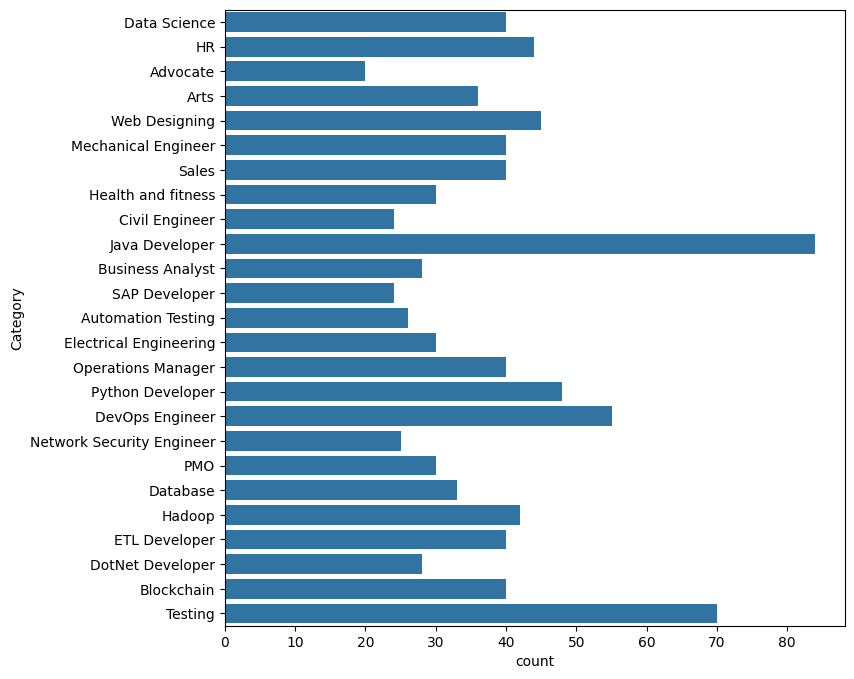

In [11]:
# YOUR CODE HERE
plt.figure(figsize= (8, 8))
sns.countplot(y= 'Category', data= df)
plt.show()

**Exercise 4: Create a pie plot depicting the percentage of resume distributions category-wise. [0.5 mark]**

**Hint:** Use [plt.pie()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pie.html) and [plt.get_cmap](https://matplotlib.org/stable/tutorials/colors/colormaps.html) for color mapping the pie chart.

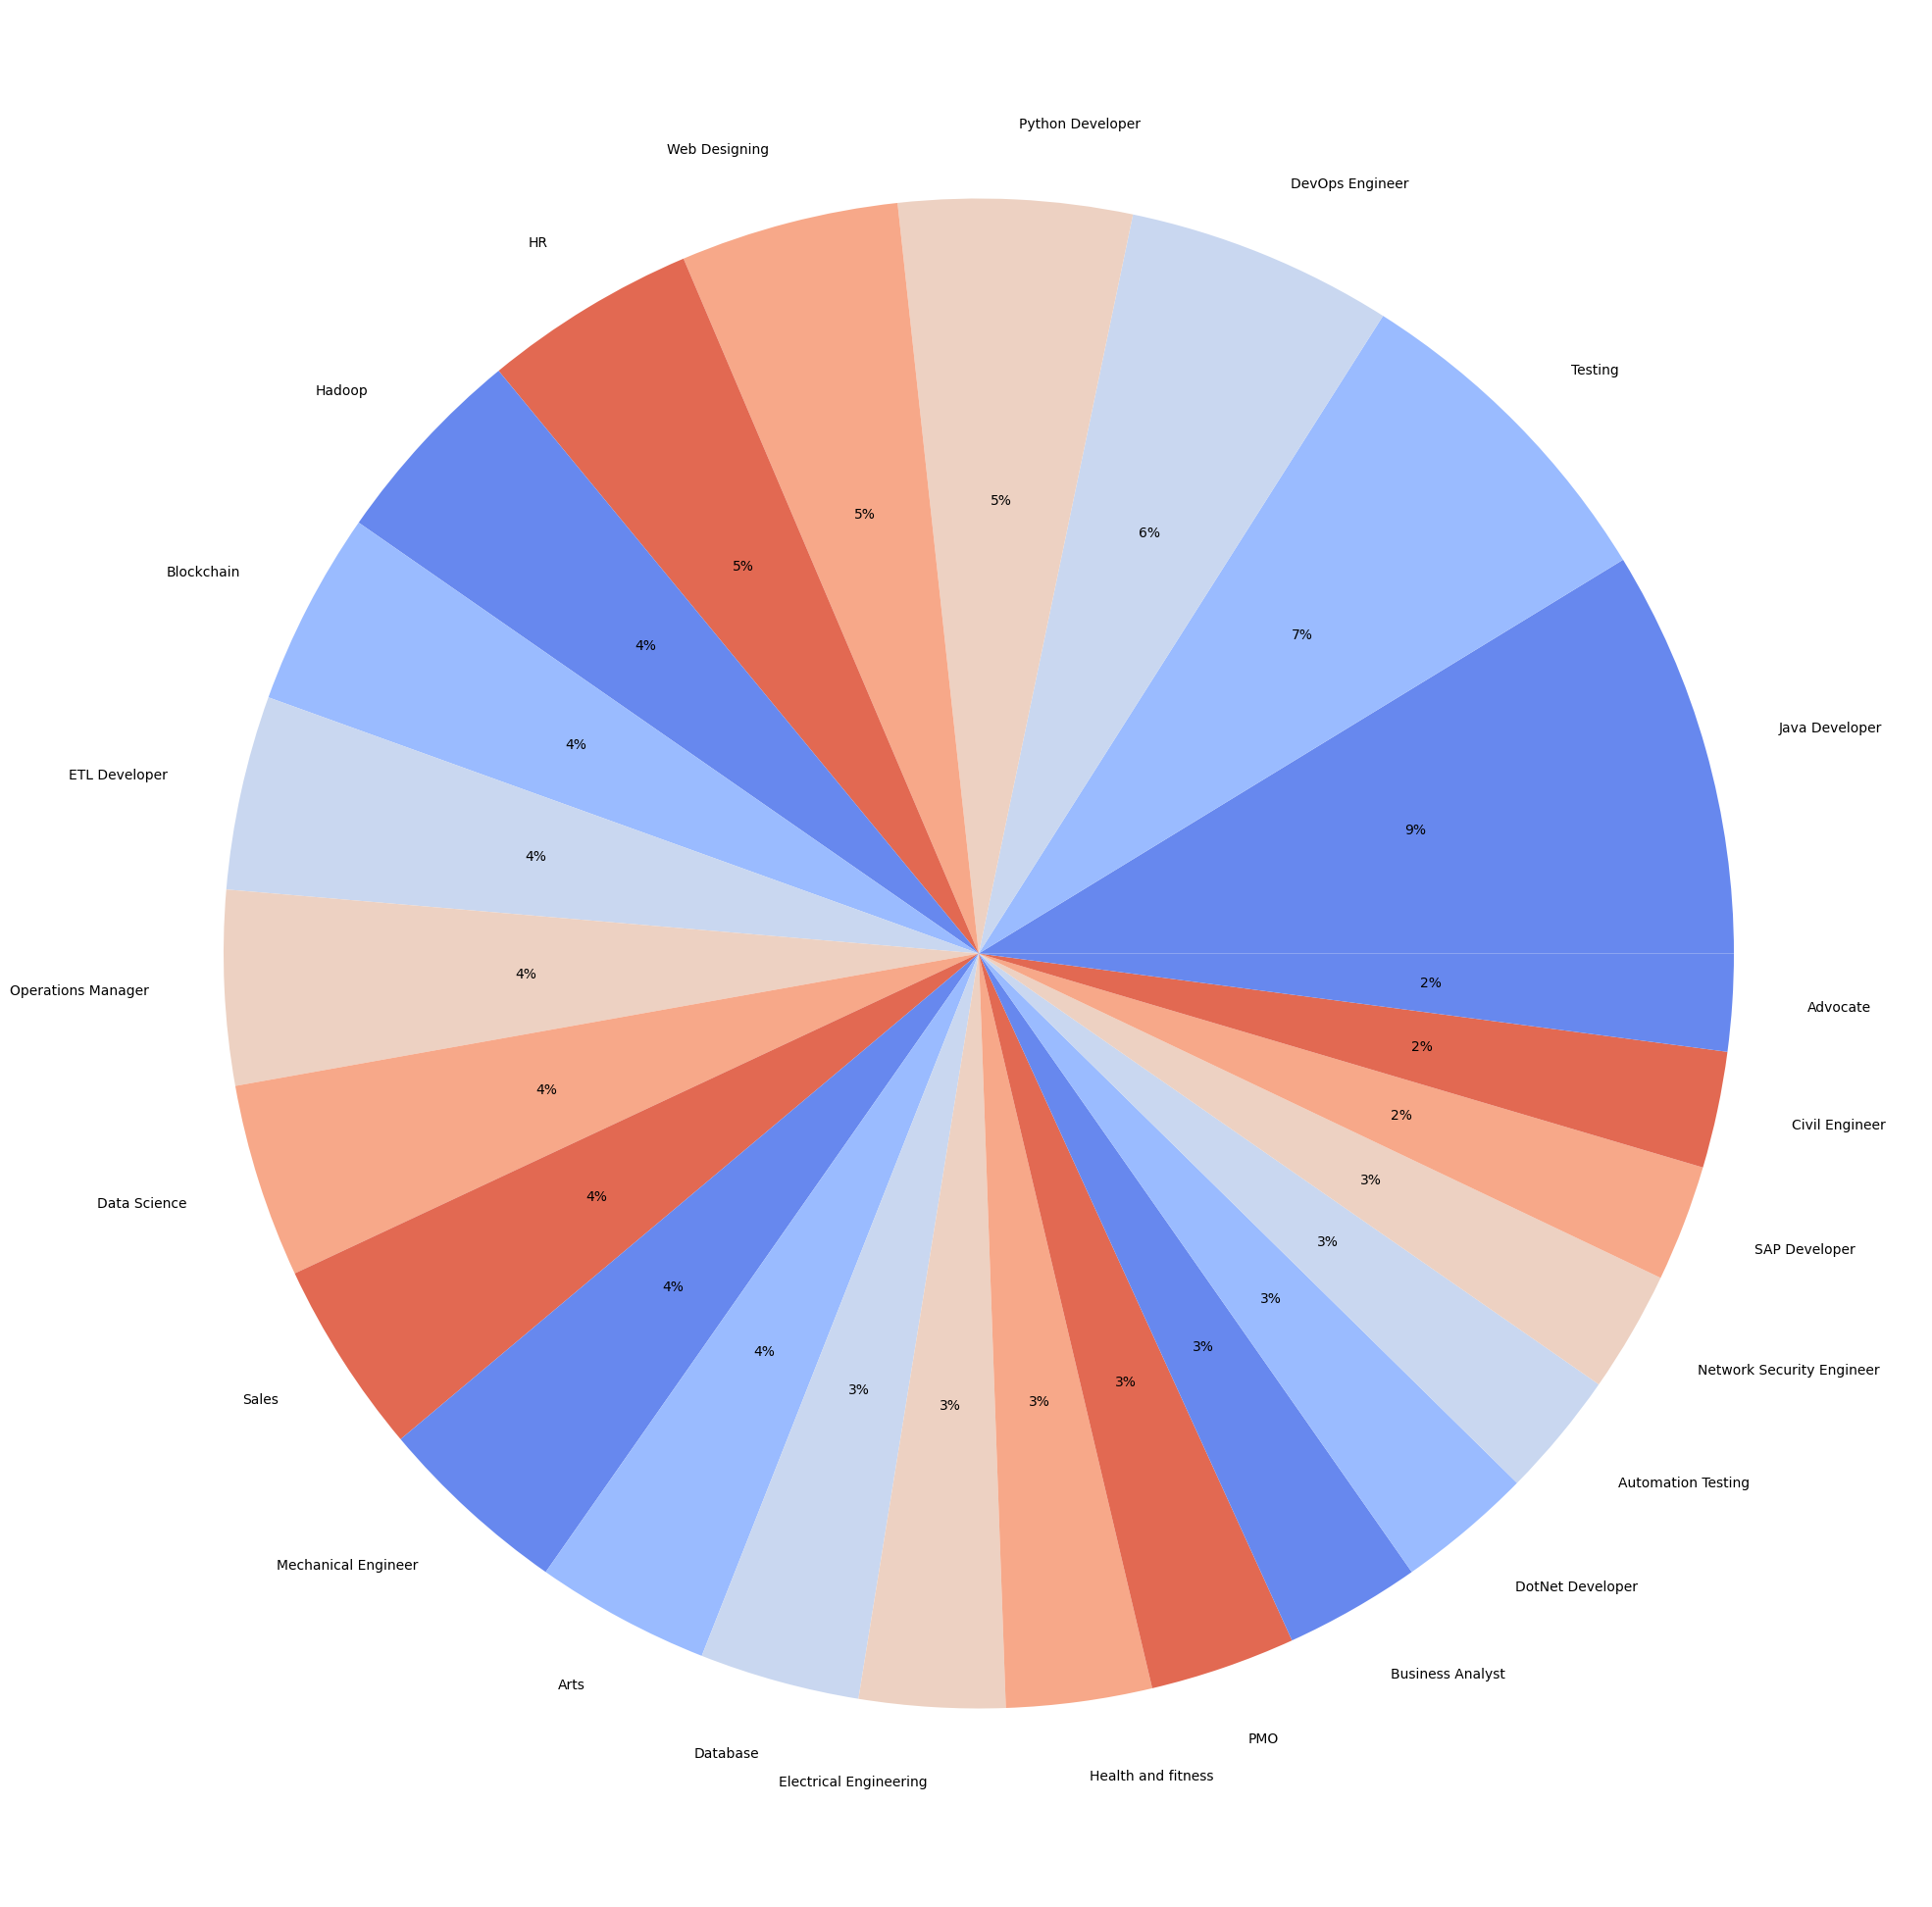

In [12]:
targetCounts = df['Category'].value_counts()
targetLabels  = targetCounts.index
# Make square figures and axes
plt.figure(1, figsize=(25,25))
the_grid = GridSpec(2, 2)



palette_color = sns.color_palette('coolwarm')

# plotting data on chart
plt.pie(targetCounts, labels=targetLabels, colors=palette_color, autopct='%.0f%%')

# displaying chart
plt.show()

**Exercise 5: Convert all the `Resume` text to lower case and remove trailing spaces [0.5 Mark]**




In [13]:
# Convert all characters to lowercase and remove trailing spaces
# YOUR CODE HERE
df['Resume'] = df['Resume'].str.lower().str.strip()

In [14]:
df['Resume'].head()


,Resume
0,skills * programming languages: python (pandas...
1,education details \r\nmay 2013 to may 2017 b.e...
2,"areas of interest deep learning, control syste..."
3,skills â¢ r â¢ python â¢ sap hana â¢ table...
4,"education details \r\n mca ymcaust, faridab..."


### Cleaning Resume

**Exercise 6: Define a function to clean the resume text [2 Mark]**

In the text there are special characters, urls, hashtags, mentions, etc. You need to remove for the following:  

* URLs: For reference click [here](https://stackoverflow.com/questions/11331982/how-to-remove-any-url-within-a-string-in-python)
* RT | cc: For reference click [here](https://www.machinelearningplus.com/python/python-regex-tutorial-examples/)
* Hashtags, # and Mentions, @
* punctuations
* extra whitespace

PS: Use the provided reference similarly for removing any other such elements.

After cleaning as above, store the Resume Text in a separate column (New Feature say `Cleaned_Resume`).


In [15]:
import re
def cleanResume(resumeText):
    # Remove URLs
    resumeText = re.sub(r'http\S+|www\S+|https\S+', '', resumeText, flags=re.MULTILINE)

    # Remove RT and cc
    resumeText = re.sub(r'\bRT\b|\bcc\b', '', resumeText, flags=re.MULTILINE)

    # Remove hashtags and mentions
    resumeText = re.sub(r'@\w+|#\w+', '', resumeText, flags=re.MULTILINE)

    # Remove punctuations
    resumeText = re.sub(r'[^\w\s]', '', resumeText)

    # Remove extra whitespace
    resumeText = re.sub(r'\s+', ' ', resumeText).strip()

    return resumeText


In [16]:
# Apply the function defined above and save the

df['Cleaned_Resume']  = df['Resume'].apply(cleanResume)


In [17]:
print(df)

         Category                                             Resume  \
0    Data Science  skills * programming languages: python (pandas...   
1    Data Science  education details \r\nmay 2013 to may 2017 b.e...   
2    Data Science  areas of interest deep learning, control syste...   
3    Data Science  skills â¢ r â¢ python â¢ sap hana â¢ table...   
4    Data Science  education details \r\n mca   ymcaust,  faridab...   
..            ...                                                ...   
957       Testing  computer skills: â¢ proficient in ms office (...   
958       Testing  â willingness to accept the challenges. â ...   
959       Testing  personal skills â¢ quick learner, â¢ eagerne...   
960       Testing  computer skills & software knowledge ms-power ...   
961       Testing  skill set os windows xp/7/8/8.1/10 database my...   

                                        Cleaned_Resume  
0    skills programming languages python pandas num...  
1    education detail

**Exercise 7: Convert the categorical variable `Category` to a numerical feature and make a different column <font color="#990000">`label`</font>, which can be treated as the target variable [0.5 Mark]**

**Hint:** Use [`sklearn.preprocessing.LabelEncoder()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) method

In [18]:
from sklearn.preprocessing import LabelEncoder

# YOUR CODE HERE
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df['Category'])
print(df[['Category', 'label']])

         Category  label
0    Data Science      6
1    Data Science      6
2    Data Science      6
3    Data Science      6
4    Data Science      6
..            ...    ...
957       Testing     23
958       Testing     23
959       Testing     23
960       Testing     23
961       Testing     23

[962 rows x 2 columns]


**Exercise 8: Plot the histogram of words count of `Cleaned_Resume` text [0.5 Mark]**

**Hint:** Use sns.distplot()

In [19]:
#df['Count'] = # YOUR CODE HERE to count number of words
# Calculate the word count for each resume
df['word_count'] = df['Cleaned_Resume'].apply(lambda x: len(x.split()))

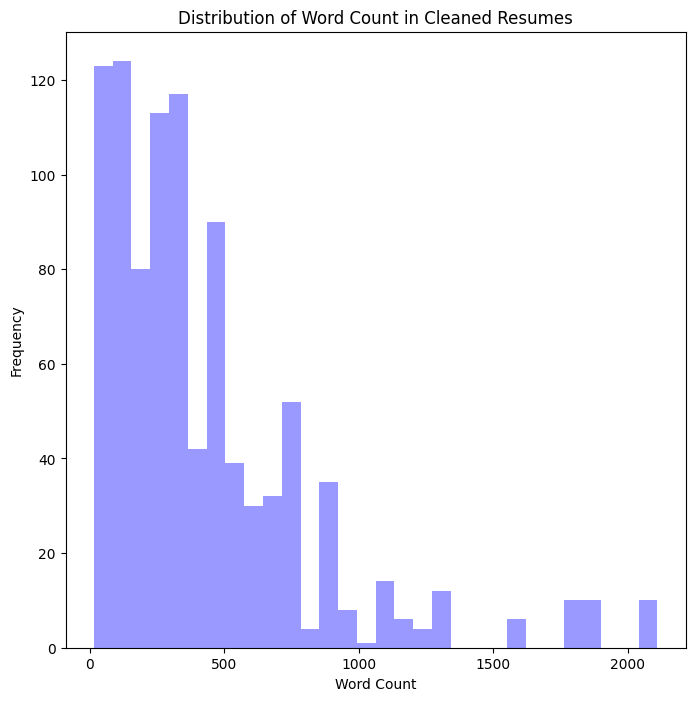

In [20]:
# Plot the histogram using seaborn
plt.figure(figsize=(8,8))
sns.distplot(df['word_count'], kde=False, bins=30, color='blue')
plt.title('Distribution of Word Count in Cleaned Resumes')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()


### Train Test Split

**Exercise 9: Split the dataset into training, validation, and testing set [0.5 Mark]**

* Do stratified splitting using `label` column

In [21]:
#train_test_df, val_df = # YOUR CODE HERE to split data
# First, split the data into a temporary train-test set and a validation set (e.g., 80%-20%)
train_test_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

#train_df, test_df = # YOUR CODE HERE to split data
# Next, split the temporary train-test set into the actual training and testing sets (e.g., 75%-25% of the 80%)
train_df, test_df = train_test_split(train_test_df, test_size=0.25, stratify=train_test_df['label'], random_state=42)

# The resulting splits are:
# - train_df: 60% of the original data
# - val_df: 20% of the original data
# - test_df: 20% of the original data

len(train_df), len(val_df), len(test_df)

(576, 193, 193)

In [22]:
train_df.head(2)

,Category,Resume,Cleaned_Resume,label,word_count
821,ETL Developer,education details \r\njanuary 2015 bachelor of...,education details january 2015 bachelor of eng...,10,275
238,Sales,it skills: ms office. photoshop. sql server.ed...,it skills ms office photoshop sql servereducat...,22,233


### Convert to HuggingFace Dataset

**Exercise 10: Convert Pandas dataframe to HuggingFace Dataset [1 Mark]**

**Hint:**

    import pandas as pd
    from datasets import Dataset, DatasetDict

    tdf = pd.DataFrame({"a": [1, 2, 3], "b": ['hello', 'ola', 'thammi']})
    vdf = pd.DataFrame({"a": [4, 5, 6], "b": ['four', 'five', 'six']})
    tds = Dataset.from_pandas(tdf)
    vds = Dataset.from_pandas(vdf)

    ds = DatasetDict()

    ds['train'] = tds
    ds['validation'] = vds

    print(ds)

In [23]:
from datasets import Dataset, DatasetDict

train_ds = pd.DataFrame(train_df)
val_ds = pd.DataFrame(val_df)
test_ds = pd.DataFrame(test_df)


train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)
ds = DatasetDict()

ds['train'] = train_dataset
ds['validation'] = val_dataset
ds['test'] = test_dataset
print(ds)

DatasetDict({
    train: Dataset({
        features: ['Category', 'Resume', 'Cleaned_Resume', 'label', 'word_count', '__index_level_0__'],
        num_rows: 576
    })
    validation: Dataset({
        features: ['Category', 'Resume', 'Cleaned_Resume', 'label', 'word_count', '__index_level_0__'],
        num_rows: 193
    })
    test: Dataset({
        features: ['Category', 'Resume', 'Cleaned_Resume', 'label', 'word_count', '__index_level_0__'],
        num_rows: 193
    })
})


### Tokenizer

**Exercise 11: Load tokenizer for checkpoint `distilbert-base-uncased` [0.5 Mark]**

**Hint:** `AutoTokenizer`

In [24]:
# Load tokenizer
#from transformers import AutoTokenizer
#tokenizer = # YOUR CODE HERE
# Load the tokenizer for distilbert-base-uncased
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
print(tokenizer)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

DistilBertTokenizerFast(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}


In [25]:
def tokenize_fn(batch):
    # YOUR CODE HERE..
    return tokenizer(batch['Cleaned_Resume'], padding=True, truncation=True)


In [26]:
tokenized_datasets = ds.map(tokenize_fn, batched=True)
tokenized_datasets
print(set(tokenized_datasets['train']['label']))

Map:   0%|          | 0/576 [00:00<?, ? examples/s]

Map:   0%|          | 0/193 [00:00<?, ? examples/s]

Map:   0%|          | 0/193 [00:00<?, ? examples/s]

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24}


### Load Pre-Trained Model

**Exercise 12: Load pre-trained Bert model with checkpoint `distilbert-base-uncased` and show model summary [0.5 Mark]**

**Hint:** `AutoModelForSequenceClassification`

In [27]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased',num_labels=25)
#print(model)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


**Exercise 13: Freeze/Un-Freeze different layers  [0.5 Mark]**

**Hint:** Freeze layers starting with name *distilbert*


In [28]:
# Display layers name

# YOUR CODE HERE
for name, module in model.named_modules():
    print(name)
    #print(module)


distilbert
distilbert.embeddings
distilbert.embeddings.word_embeddings
distilbert.embeddings.position_embeddings
distilbert.embeddings.LayerNorm
distilbert.embeddings.dropout
distilbert.transformer
distilbert.transformer.layer
distilbert.transformer.layer.0
distilbert.transformer.layer.0.attention
distilbert.transformer.layer.0.attention.dropout
distilbert.transformer.layer.0.attention.q_lin
distilbert.transformer.layer.0.attention.k_lin
distilbert.transformer.layer.0.attention.v_lin
distilbert.transformer.layer.0.attention.out_lin
distilbert.transformer.layer.0.sa_layer_norm
distilbert.transformer.layer.0.ffn
distilbert.transformer.layer.0.ffn.dropout
distilbert.transformer.layer.0.ffn.lin1
distilbert.transformer.layer.0.ffn.lin2
distilbert.transformer.layer.0.ffn.activation
distilbert.transformer.layer.0.output_layer_norm
distilbert.transformer.layer.1
distilbert.transformer.layer.1.attention
distilbert.transformer.layer.1.attention.dropout
distilbert.transformer.layer.1.attention.q

In [29]:
# Freezing

# YOUR CODE HERE..

# Freeze layers starting with 'distilbert'
for name, param in model.named_parameters():
    if name.startswith('distilbert'):
        param.requires_grad = False

# Check which layers are frozen
frozen_params = [name for name, param in model.named_parameters() if not param.requires_grad]
print("Frozen parameters:", frozen_params)

Frozen parameters: ['distilbert.embeddings.word_embeddings.weight', 'distilbert.embeddings.position_embeddings.weight', 'distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias', 'distilbert.transformer.layer.0.attention.q_lin.weight', 'distilbert.transformer.layer.0.attention.q_lin.bias', 'distilbert.transformer.layer.0.attention.k_lin.weight', 'distilbert.transformer.layer.0.attention.k_lin.bias', 'distilbert.transformer.layer.0.attention.v_lin.weight', 'distilbert.transformer.layer.0.attention.v_lin.bias', 'distilbert.transformer.layer.0.attention.out_lin.weight', 'distilbert.transformer.layer.0.attention.out_lin.bias', 'distilbert.transformer.layer.0.sa_layer_norm.weight', 'distilbert.transformer.layer.0.sa_layer_norm.bias', 'distilbert.transformer.layer.0.ffn.lin1.weight', 'distilbert.transformer.layer.0.ffn.lin1.bias', 'distilbert.transformer.layer.0.ffn.lin2.weight', 'distilbert.transformer.layer.0.ffn.lin2.bias', 'distilbert.transformer.layer.0.output_lay

In [30]:
# Display layers gradient

# YOUR CODE HERE..
print("Layer gradients:")
for name, param in model.named_parameters():
    if param.grad is not None:
        print(f"Layer: {name}")
        print(f"Gradient: {param.grad}")
    else:
        print(f"Layer: {name} does not have a gradient")

Layer gradients:
Layer: distilbert.embeddings.word_embeddings.weight does not have a gradient
Layer: distilbert.embeddings.position_embeddings.weight does not have a gradient
Layer: distilbert.embeddings.LayerNorm.weight does not have a gradient
Layer: distilbert.embeddings.LayerNorm.bias does not have a gradient
Layer: distilbert.transformer.layer.0.attention.q_lin.weight does not have a gradient
Layer: distilbert.transformer.layer.0.attention.q_lin.bias does not have a gradient
Layer: distilbert.transformer.layer.0.attention.k_lin.weight does not have a gradient
Layer: distilbert.transformer.layer.0.attention.k_lin.bias does not have a gradient
Layer: distilbert.transformer.layer.0.attention.v_lin.weight does not have a gradient
Layer: distilbert.transformer.layer.0.attention.v_lin.bias does not have a gradient
Layer: distilbert.transformer.layer.0.attention.out_lin.weight does not have a gradient
Layer: distilbert.transformer.layer.0.attention.out_lin.bias does not have a gradient
L

### Metrics

In [31]:
from datasets import load_metric
metric = load_metric("glue", "sst2")         # Type 'Y' when prompted

The repository for glue contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/glue.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


In [32]:
metric.compute(predictions=[1,0,1], references=[1,0,0])

{'accuracy': 0.6666666666666666}

In [33]:
def compute_metrics(logits_and_labels):
    logits, labels = logits_and_labels
    predictions = np.argmax(logits,axis=-1)
    return metric.compute(predictions=predictions,references=labels)


**Exercise 14: Fine-tune model on train dataset  [0.5 Mark]**
 * Create `TrainingArguments` class object
 * Create `Trainer` class  object
 * Train it for higher number of epochs say 40 or 50
 * Switch to GPU runtime if needed

**Hint:** Check if the training code is running without any error with CPU runtime, later switch to GPU runtime for faster training. Once trained, save the model, create its zip file, and download into your system.

In [34]:
from transformers import TrainingArguments
from transformers import Trainer

In [35]:
# Set up the training arguments
#training_args = # YOUR CODE HERE..
training_args = TrainingArguments(
    output_dir='./results',              # Output directory
    evaluation_strategy="epoch",         # Evaluate after each epoch
    learning_rate=2e-5,                  # Learning rate
    per_device_train_batch_size=8,       # Batch size for training
    per_device_eval_batch_size=8,        # Batch size for evaluation
    num_train_epochs=40,                 # Number of training epochs
    weight_decay=0.01,                   # Strength of weight decay
    logging_dir='./logs',                # Directory for storing logs
    logging_steps=10,                    # Frequency of logging
)
model_output_path = "/content/bert_model"



In [36]:
# Train the model

# Create Trainer instance
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,3.208800,3.188108,0.124352
2,3.165300,3.154831,0.124352
3,3.134100,3.126504,0.139896
4,3.107100,3.103089,0.134715
5,3.152400,3.081539,0.139896
6,3.094800,3.061805,0.139896
7,3.036100,3.041791,0.139896
8,3.050000,3.023834,0.139896
9,3.030100,3.005622,0.134715
10,3.006800,2.988456,0.139896


TrainOutput(global_step=2880, training_loss=2.8681907289557986, metrics={'train_runtime': 532.2553, 'train_samples_per_second': 43.287, 'train_steps_per_second': 5.411, 'total_flos': 3053300731084800.0, 'train_loss': 2.8681907289557986, 'epoch': 40.0})

### Save Model

In [37]:
# Save the model
trainer.save_model('saved_bert_model')

In [38]:
!ls

logs  results  sample_data  saved_bert_model  UpdatedResumeDataSet.csv


In [39]:
# Create a Zip file and download
!zip -r saved_bert_model.zip saved_bert_model

  adding: saved_bert_model/ (stored 0%)
  adding: saved_bert_model/config.json (deflated 64%)
  adding: saved_bert_model/training_args.bin (deflated 51%)
  adding: saved_bert_model/model.safetensors (deflated 8%)


### Load Model

**Exercise 15: Load the saved model and create a pipeline to perform text classification [1 Mark]**

 * Create the pipeline object for text classification
 * Create a `make_prediction` function to use pipeline object and output the prediction label

**Hint:** pipeline()

In [40]:
from transformers import pipeline

In [42]:
#my_model = # YOUR CODE HERE.. to load text classification pipeline
my_model = pipeline("text-classification", model=model, tokenizer=tokenizer)

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


In [43]:
# Function to predict label for a resume text

def make_prediction(input_text):

    # YOUR CODE HERE..
    result = my_model(input_text)
    predicted_label = result[0]['label']
    return predicted_label


In [44]:
# Test prediction
make_prediction('programming, web designing, coding')

'LABEL_15'

In [45]:
make_prediction('continuous integration and continuous delivery')

'LABEL_15'

In [46]:
make_prediction('law student and journalist')

'LABEL_12'

In [47]:
make_prediction('machine learning, data, EDA, big data, neural networks')

'LABEL_15'

## **Optional**: Create a Gradio based web interface to test and display the model predictions

In [48]:
!pip -q install gradio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.9/141.9 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 109.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.2/93.2 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 11.4 MB/s eta 0:00:00


In [49]:
import gradio

In [50]:
# Textbox to take Input from user
in_text = gradio.Textbox(lines=10, placeholder=None, value="Enter resume text here", label='Resume Text')


# Textbox to display Output prediction
out_label = gradio.Textbox(type="text", label='Predicted Class Label')


# Gradio interface to create UI
iface = gradio.Interface(fn = make_prediction,             # fine-tuned model is used inside this function
                         inputs = [in_text],
                         outputs = [out_label],
                         title = "Resume Classification",
                         description = "Using fine-tuned Bert model",
                         allow_flagging = 'never')


# Launch interface
iface.launch(share = True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Running on public URL: https://3a94d08f00f07c52f8.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)
